## Setup

In [5]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import models
import torchvision.transforms.functional as TF
import torchvision

import numpy as np
import matplotlib.pyplot as plt

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


## Carregar Modelo

In [7]:
def get_pretrained_model_optimized():
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    model.fc = nn.Linear(model.fc.in_features, 10)
    return model.to(device)

In [8]:
classes = ["airplane", "bird", "car", "cat", "deer", "dog", "horse", "monkey", "ship", "truck"]

stats_stl10 = ((0.4467, 0.4398, 0.4066), (0.2603, 0.2566, 0.2713))
BATCH_SIZE = 64

transform_pt_train = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(*stats_stl10),
])
transform_pt_test = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(*stats_stl10),
])

testset_pt = torchvision.datasets.STL10(root='./data', split='test', download=True, transform=transform_pt_test)
loader_pt_test = torch.utils.data.DataLoader(testset_pt, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [9]:
model_loaded = get_pretrained_model_optimized()
model_loaded.load_state_dict(torch.load('./models/model_resnet_stl10.pth', map_location=device))
model_loaded.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Funções Auxiliares

In [10]:
def fgsm_attack(image, epsilon, data_grad):
    """
    Gera a perturbação adversarial.
    """
    # 1. Pega o sinal do gradiente (direção do maior erro)
    sign_data_grad = data_grad.sign()
    
    # 2. Cria a imagem perturbada: x + epsilon * sign(grad)
    perturbed_image = image + epsilon * sign_data_grad
    
    return perturbed_image

In [11]:
def test_adversarial_accuracy(model, loader, device, epsilons):
    """
    Roda o ataque FGSM para vários valores de epsilon e retorna as acurácias.
    """
    model.eval()
    accuracies = []
    examples = [] # Para visualização posterior

    print(f"--- Iniciando Ataque FGSM ---")
    
    for eps in epsilons:
        correct = 0
        total = 0
        adv_examples_bucket = [] # Exemplos deste epsilon específico
        
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Importante: Precisamos rastrear o gradiente da IMAGEM de entrada
            inputs.requires_grad = True
            
            # Forward pass
            outputs = model(inputs)
            init_pred = outputs.max(1, keepdim=True)[1]
            
            # Se o modelo já errou a original, não conta para o ataque (opcional, mas comum)
            # Aqui vamos contar tudo para ver a queda bruta de performance
            
            loss = nn.CrossEntropyLoss()(outputs, labels)
            model.zero_grad()
            loss.backward()
            
            # Coleta o gradiente da imagem
            data_grad = inputs.grad.data
            
            # Chama o ataque
            perturbed_data = fgsm_attack(inputs, eps, data_grad)
            
            # Re-classifica a imagem atacada
            output_adv = model(perturbed_data)
            final_pred = output_adv.max(1, keepdim=True)[1]
            
            # Calcula acurácia
            # Comparação batch a batch
            matches = final_pred.eq(labels.view_as(final_pred))
            correct += matches.sum().item()
            total += inputs.size(0)
            
            # Salva o primeiro exemplo de sucesso do ataque neste batch para plotar
            if len(adv_examples_bucket) < 1:
                adv_ex = perturbed_data[0].detach().cpu()
                orig_ex = inputs[0].detach().cpu()
                orig_pred = init_pred[0].item()
                adv_pred = final_pred[0].item()
                true_label = labels[0].item()
                
                adv_examples_bucket.append((orig_ex, adv_ex, true_label, orig_pred, adv_pred))

        acc = 100. * correct / total
        accuracies.append(acc)
        examples.append(adv_examples_bucket[0]) # Salva 1 exemplo por epsilon
        
        print(f"Epsilon: {eps:.4f} \tAcurácia: {acc:.2f}%")
        
    return accuracies, examples

In [12]:
def visualize_attack(examples, indices_to_show, classes, stats):
    """
    Plota: Original -> Ruído -> Adversarial
    """
    mean, std = stats
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    
    for idx in indices_to_show:
        if idx >= len(examples): break
        
        orig_tensor, adv_tensor, true_lbl, orig_pred, adv_pred = examples[idx]
        eps = epsilons[idx]
        
        # Desnormalizar
        img_orig = (orig_tensor * std + mean).clamp(0, 1).permute(1,2,0).numpy()
        img_adv  = (adv_tensor * std + mean).clamp(0, 1).permute(1,2,0).numpy()
        
        # Calcular o Ruído (A diferença pura)
        noise = (adv_tensor - orig_tensor).permute(1,2,0).numpy()
        # Normaliza o ruído para visualização (senão fica tudo preto/cinza)
        noise = (noise - noise.min()) / (noise.max() - noise.min() + 1e-8)
        
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        # 1. Original
        axes[0].imshow(img_orig)
        axes[0].set_title(f"Original\nReal: {classes[true_lbl]} | Pred: {classes[orig_pred]}")
        axes[0].axis('off')
        
        # 2. Ruído
        axes[1].imshow(noise, cmap='gray')
        axes[1].set_title(f"Perturbação (Epsilon={eps})\n(Contraste Aumentado)")
        axes[1].axis('off')
        
        # 3. Adversarial
        axes[2].imshow(img_adv)
        axes[2].set_title(f"Adversarial\nPredição: {classes[adv_pred]}")
        axes[2].axis('off')
        
        plt.tight_layout()
        plt.show()

## Ataque FGSM (Fast Gradient Sign Method)

--- Iniciando Ataque FGSM ---


Epsilon: 0.0000 	Acurácia: 95.20%
Epsilon: 0.0025 	Acurácia: 80.10%
Epsilon: 0.0050 	Acurácia: 61.74%
Epsilon: 0.0075 	Acurácia: 45.79%
Epsilon: 0.0100 	Acurácia: 34.41%
Epsilon: 0.0200 	Acurácia: 17.01%
Epsilon: 0.0300 	Acurácia: 11.61%
Epsilon: 0.0400 	Acurácia: 9.20%
Epsilon: 0.0500 	Acurácia: 7.84%
Epsilon: 0.0600 	Acurácia: 7.33%
Epsilon: 0.0700 	Acurácia: 7.06%
Epsilon: 0.0800 	Acurácia: 7.08%
Epsilon: 0.0900 	Acurácia: 7.17%
Epsilon: 0.1000 	Acurácia: 7.28%


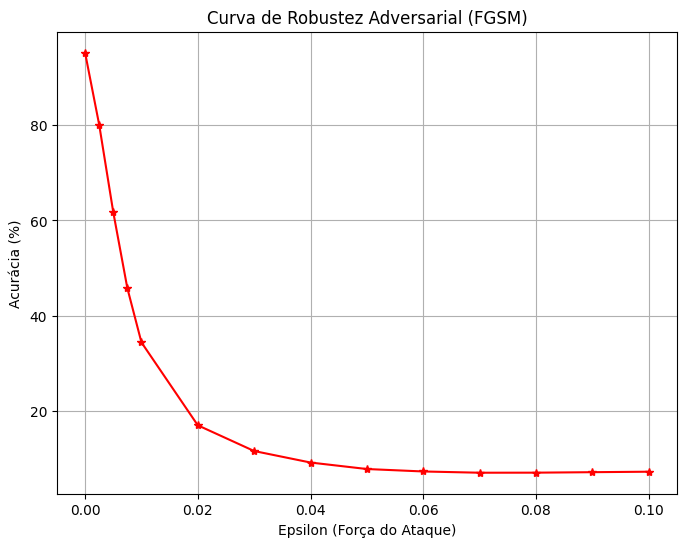

In [33]:
# Definindo as forças do ataque
# 0.0 = Baseline
# 0.3 = Ataque muito forte (a imagem começa a ficar visivelmente ruidosa)
epsilons = [0, 0.0025, 0.005, 0.0075 , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]

accuracies, adv_examples = test_adversarial_accuracy(model_loaded, loader_pt_test, device, epsilons)

# --- Plotando a Curva de Queda ---
plt.figure(figsize=(8, 6))
plt.plot(epsilons, accuracies, "*-", color='red')
plt.title("Curva de Robustez Adversarial (FGSM)")
plt.xlabel("Epsilon (Força do Ataque)")
plt.ylabel("Acurácia (%)")
plt.grid(True)
plt.show()

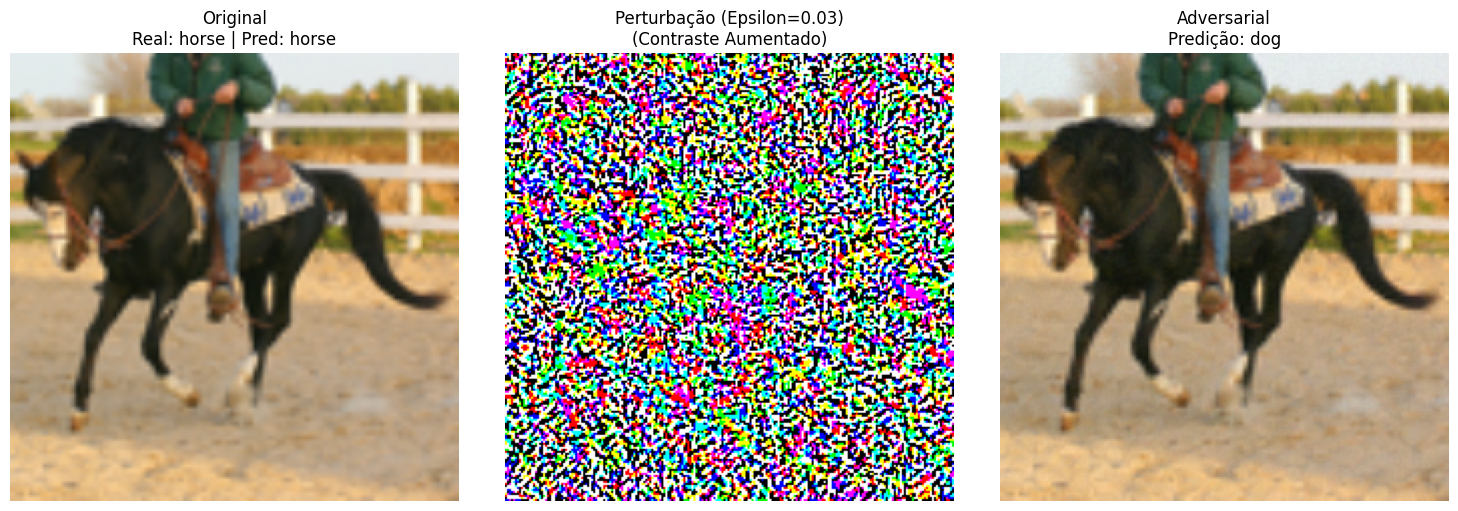

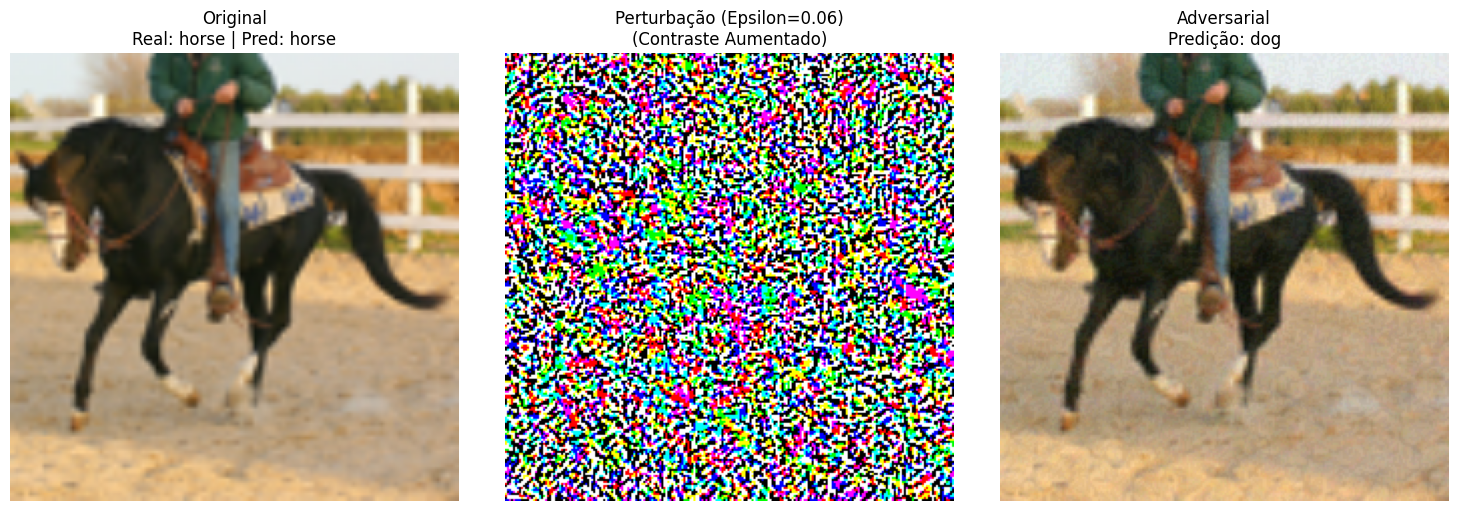

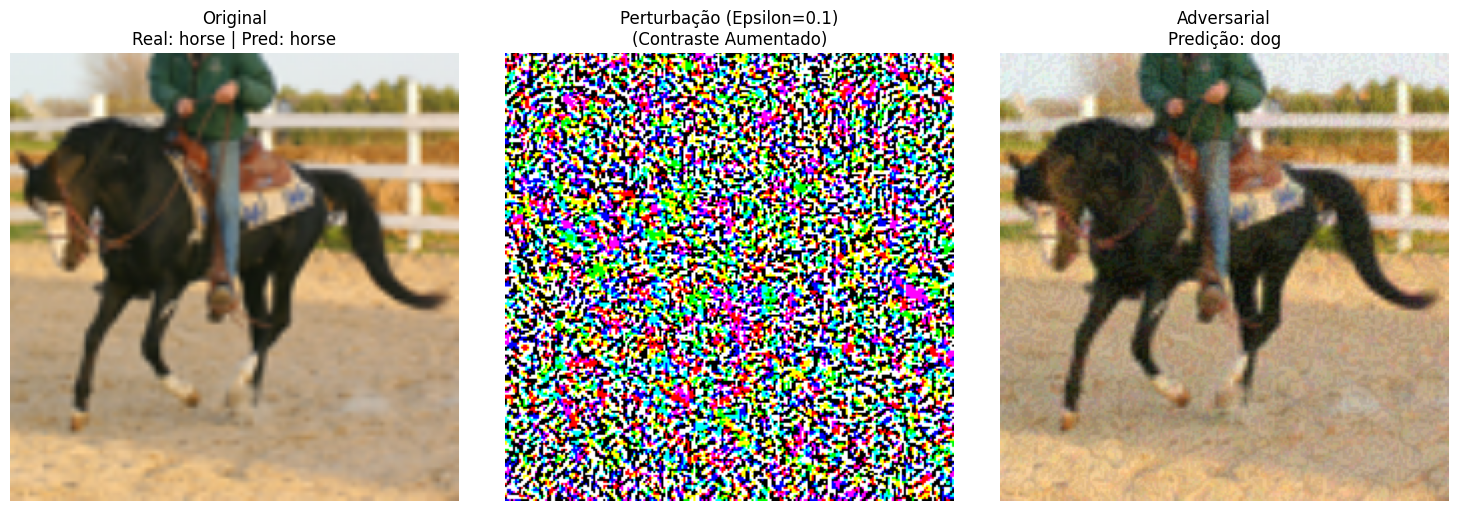

In [35]:
# Rodar visualização
indices_to_show = [6, 9, 13]
visualize_attack(adv_examples, indices_to_show, loader_pt_test.dataset.classes, stats_stl10)

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_side_by_side(attr_tensor, original_img_tensor, stats, title="Atribuição"):
    """
    Plota lado a lado: Imagem Original vs. Heatmap dos Gradientes (sem fundo).
    """
    # --- 1. Processar Imagem Original ---
    mean, std = stats
    mean = torch.tensor(mean).view(3, 1, 1).to(original_img_tensor.device)
    std = torch.tensor(std).view(3, 1, 1).to(original_img_tensor.device)
    
    img_denorm = original_img_tensor.clone() * std + mean
    img_np = img_denorm.clamp(0, 1).squeeze(0).permute(1, 2, 0).cpu().detach().numpy()

    # --- 2. Processar o Heatmap (Saliency Map) ---
    # attr_tensor vem como [1, 3, H, W]
    attr_np = attr_tensor.squeeze(0).cpu().detach().numpy()
    
    # Achatar os canais: Calcula a magnitude média da importância entre R, G e B
    # Resultado: uma matriz 2D [H, W]
    heatmap = np.mean(np.abs(attr_np), axis=0)
    
    # Normalização Min-Max para o plot ficar brilhante (0 a 1)
    # Adicionamos 1e-8 para evitar divisão por zero se o gradiente for todo zero
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

    # --- 3. Plotagem ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Esquerda: Imagem Original
    axes[0].imshow(img_np)
    axes[0].set_title("Imagem Original")
    axes[0].axis('off')
    
    # Direita: Heatmap Puro
    # cmap='inferno' ou 'hot' são ótimos para fundo preto
    # cmap='gray' é bom para parecer um "Raio-X"
    im = axes[1].imshow(heatmap, cmap='inferno', vmin=0, vmax=1)
    axes[1].set_title(f"Saliency Map (IG)\n{title}")
    axes[1].axis('off')
    
    # Barra de cores lateral
    cbar = fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    cbar.set_label('Importância Relativa')

    plt.tight_layout()
    plt.show()

--- Explicando a Imagem Atacada (Epsilon 0.05) ---
Classe Real: horse
Modelo Prevê: dog


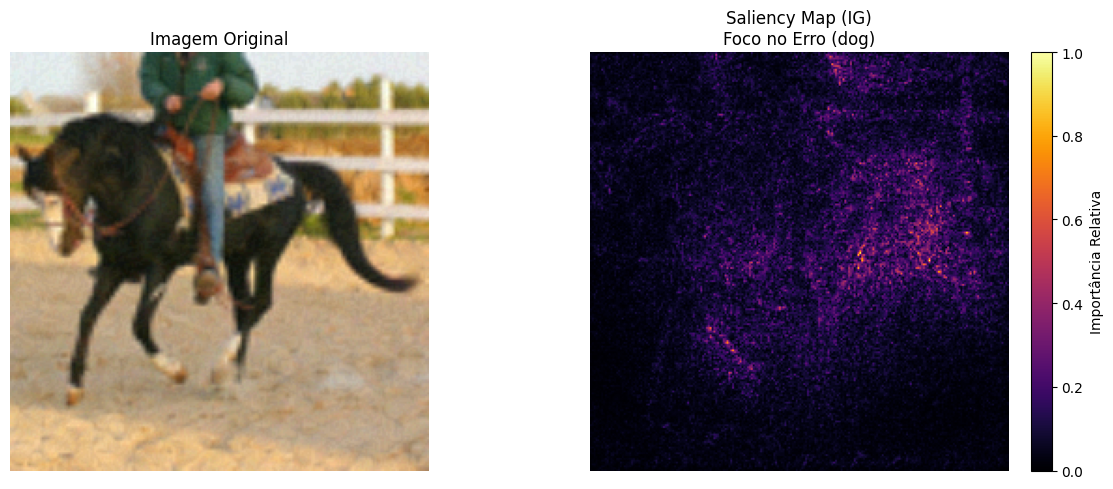

In [14]:
idx_eps = 8
orig_tensor, adv_tensor, true_lbl, orig_pred, adv_pred = adv_examples[idx_eps]

# Enviar para device
adv_tensor_gpu = adv_tensor.unsqueeze(0).to(device)
orig_tensor_gpu = orig_tensor.unsqueeze(0).to(device)

print(f"--- Explicando a Imagem Atacada (Epsilon {epsilons[idx_eps]}) ---")
print(f"Classe Real: {loader_pt_test.dataset.classes[true_lbl]}")
print(f"Modelo Prevê: {loader_pt_test.dataset.classes[adv_pred]}")

# Usar sua função de Integrated Gradients da etapa anterior
# Importante: Explicar a predição ERRADA (adv_pred)
from captum.attr import IntegratedGradients, NoiseTunnel
ig = IntegratedGradients(model_loaded)
nt = NoiseTunnel(ig)

attr_adv = nt.attribute(
    adv_tensor_gpu, 
    nt_type='smoothgrad', 
    n_steps=30, 
    nt_samples=10, 
    target=adv_pred # Queremos ver por que ele escolheu a classe errada
)

# Plotar usando sua função visualizadora
visualize_side_by_side(attr_adv, adv_tensor_gpu, stats_stl10, title=f"Foco no Erro ({loader_pt_test.dataset.classes[adv_pred]})")

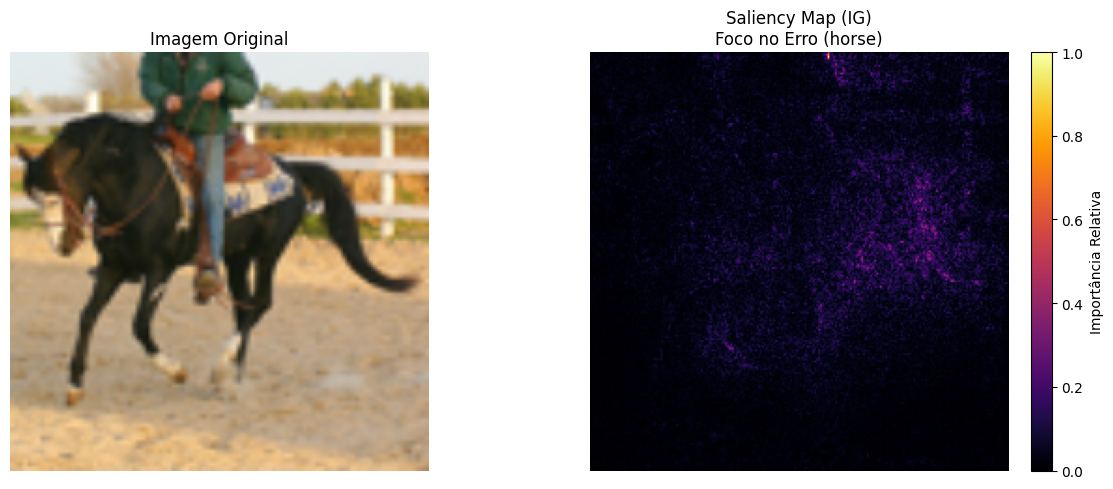

In [13]:
attr_orig = nt.attribute(
    orig_tensor_gpu, 
    nt_type='smoothgrad', 
    n_steps=30, 
    nt_samples=10, 
    target=adv_pred # Queremos ver por que ele escolheu a classe errada
)

# Plotar usando sua função visualizadora
visualize_side_by_side(attr_orig, orig_tensor_gpu, stats_stl10, title=f"Foco no Erro ({loader_pt_test.dataset.classes[orig_pred]})")

## PGD (Projected Gradient Descent)

In [14]:
import torch
import torch.nn as nn

def pgd_attack(model, images, labels, eps, alpha, steps, device):
    """
    Projected Gradient Descent (PGD) Attack.
    
    Args:
        eps (float): Máxima perturbação permitida (Epsilon).
        alpha (float): Tamanho do passo a cada iteração (Step size).
        steps (int): Número de iterações.
    """
    # 1. Clone a imagem original para não alterar o dataset
    images = images.clone().detach().to(device)
    labels = labels.clone().detach().to(device)
    
    # Adiciona um ruído inicial aleatório uniforme entre -eps e +eps
    adv_images = images + torch.empty_like(images).uniform_(-eps, eps)
    adv_images = torch.clamp(adv_images, min=images.min(), max=images.max()).detach()
    
    loss_fn = nn.CrossEntropyLoss()

    for _ in range(steps):
        adv_images.requires_grad = True
        
        # Forward pass
        outputs = model(adv_images)
        loss = loss_fn(outputs, labels)
        
        # Zero grad dos pesos (boa prática) e Backward na imagem
        model.zero_grad()
        loss.backward()
        
        # Update Iterativo
        with torch.no_grad():
            # A. Calcula o passo
            grad = adv_images.grad
            adv_images = adv_images + alpha * grad.sign()
            
            # B. Projeção (O "P" do PGD)
            # Garante que o ruído total não exceda epsilon (corta o excesso)
            eta = torch.clamp(adv_images - images, min=-eps, max=eps)
            
            # C. Aplica o ruído projetado na imagem original
            adv_images = images + eta
            
            # D. Clamp final para manter valores de pixel válidos
            # Limpa gradiente para próxima iteração
            adv_images.grad = None

    return adv_images

In [27]:
def compare_attacks(model, loader, device, epsilons):
    model.eval()
    
    print(f"{'Epsilon':<10} | {'Acc Limpa':<10} | {'Acc FGSM':<10} | {'Acc PGD':<10}")
    print("-" * 50)
    
    results = {'eps': [], 'fgsm': [], 'pgd': []}

    for eps in epsilons:
        # Configuração padrão do PGD
        steps = 10
        alpha = eps / 4 if eps > 0 else 0.01
        
        correct_clean = 0
        correct_fgsm = 0
        correct_pgd = 0
        total = 0
        
        # Vamos usar apenas os primeiros 100 itens para não demorar muito
        # (Remova o break se quiser precisão total no dataset inteiro)
        for i, (inputs, labels) in enumerate(loader):
            if i >= 4: break # Roda apenas ~250 imagens (4 batches de 64) para teste rápido
            
            inputs, labels = inputs.to(device), labels.to(device)
            total += labels.size(0)
            
            # 1. Acurácia Limpa (Baseline do batch atual)
            with torch.no_grad():
                out_clean = model(inputs)
                pred_clean = out_clean.max(1)[1]
                correct_clean += pred_clean.eq(labels).sum().item()
            
            # 2. Ataque FGSM
            # Precisamos calcular o gradiente de novo pois o pgd é separado
            inputs.requires_grad = True
            loss = nn.CrossEntropyLoss()(model(inputs), labels)
            model.zero_grad()
            loss.backward()
            data_grad = inputs.grad.data
            
            adv_fgsm = inputs + eps * data_grad.sign()
            with torch.no_grad():
                out_fgsm = model(adv_fgsm)
                correct_fgsm += out_fgsm.max(1)[1].eq(labels).sum().item()
            
            # 3. Ataque PGD
            adv_pgd = pgd_attack(model, inputs, labels, eps, alpha, steps, device)
            with torch.no_grad():
                out_pgd = model(adv_pgd)
                correct_pgd += out_pgd.max(1)[1].eq(labels).sum().item()
        
        acc_clean = 100. * correct_clean / total
        acc_fgsm = 100. * correct_fgsm / total
        acc_pgd = 100. * correct_pgd / total
        
        results['eps'].append(eps)
        results['fgsm'].append(acc_fgsm)
        results['pgd'].append(acc_pgd)
        
        print(f"{eps:<10.4f} | {acc_clean:<10.1f} | {acc_fgsm:<10.1f} | {acc_pgd:<10.1f}")
        
    return results

In [28]:
epsilons_comp = np.arange(0.0005, 0.0101, 0.0005)

In [29]:


comp_results = compare_attacks(model_loaded, loader_pt_test, device, epsilons_comp)

Epsilon    | Acc Limpa  | Acc FGSM   | Acc PGD   
--------------------------------------------------
0.0005     | 94.5       | 92.2       | 92.2      
0.0010     | 94.5       | 89.5       | 89.1      
0.0015     | 94.5       | 85.2       | 84.4      
0.0020     | 94.5       | 82.0       | 80.1      
0.0025     | 94.5       | 78.9       | 75.0      
0.0030     | 94.5       | 76.2       | 69.9      
0.0035     | 94.5       | 73.8       | 61.3      
0.0040     | 94.5       | 69.1       | 55.9      
0.0045     | 94.5       | 63.7       | 49.2      
0.0050     | 94.5       | 60.2       | 41.4      
0.0055     | 94.5       | 56.2       | 37.1      
0.0060     | 94.5       | 53.9       | 32.0      
0.0065     | 94.5       | 50.8       | 25.4      
0.0070     | 94.5       | 48.4       | 21.9      
0.0075     | 94.5       | 45.3       | 19.9      
0.0080     | 94.5       | 43.0       | 16.8      
0.0085     | 94.5       | 40.6       | 13.3      
0.0090     | 94.5       | 37.5       | 12.5      

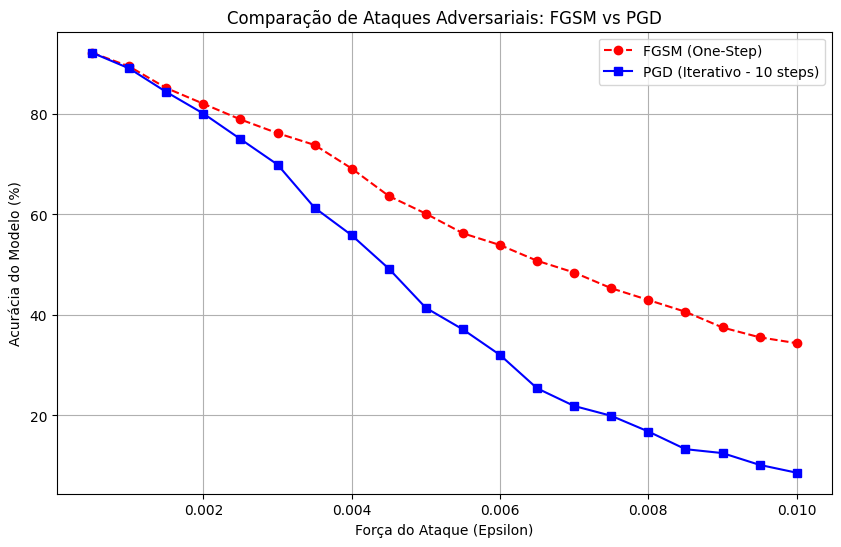

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(comp_results['eps'], comp_results['fgsm'], 'o--', label='FGSM (One-Step)', color='red')
plt.plot(comp_results['eps'], comp_results['pgd'], 's-', label='PGD (Iterativo - 10 steps)', color='blue')

plt.title("Comparação de Ataques Adversariais: FGSM vs PGD")
plt.xlabel("Força do Ataque (Epsilon)")
plt.ylabel("Acurácia do Modelo (%)")
plt.legend()
plt.grid(True)
plt.show()